In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

n = 500

data = pd.DataFrame({
    'study_hours': np.random.uniform(1, 10, n),
    'attendance': np.random.uniform(50, 100, n),
    'sleep_hours': np.random.uniform(4, 9, n),
    'previous_score': np.random.uniform(40, 90, n)
})

# Target variable
data['final_score'] = (
    data['study_hours'] * 5 +
    data['attendance'] * 0.3 +
    data['sleep_hours'] * 2 +
    data['previous_score'] * 0.5 +
    np.random.normal(0, 5, n)
)

data.head()

,study_hours,attendance,sleep_hours,previous_score,final_score
0,4.370861,84.908086,4.925665,65.954089,85.765192
1,9.556429,76.804818,6.709505,63.959094,112.087744
2,7.587945,65.476381,8.364729,41.282103,93.820757
3,6.387926,90.689751,7.661124,57.062391,104.836829
4,2.404168,84.236559,8.032806,59.009781,87.430231


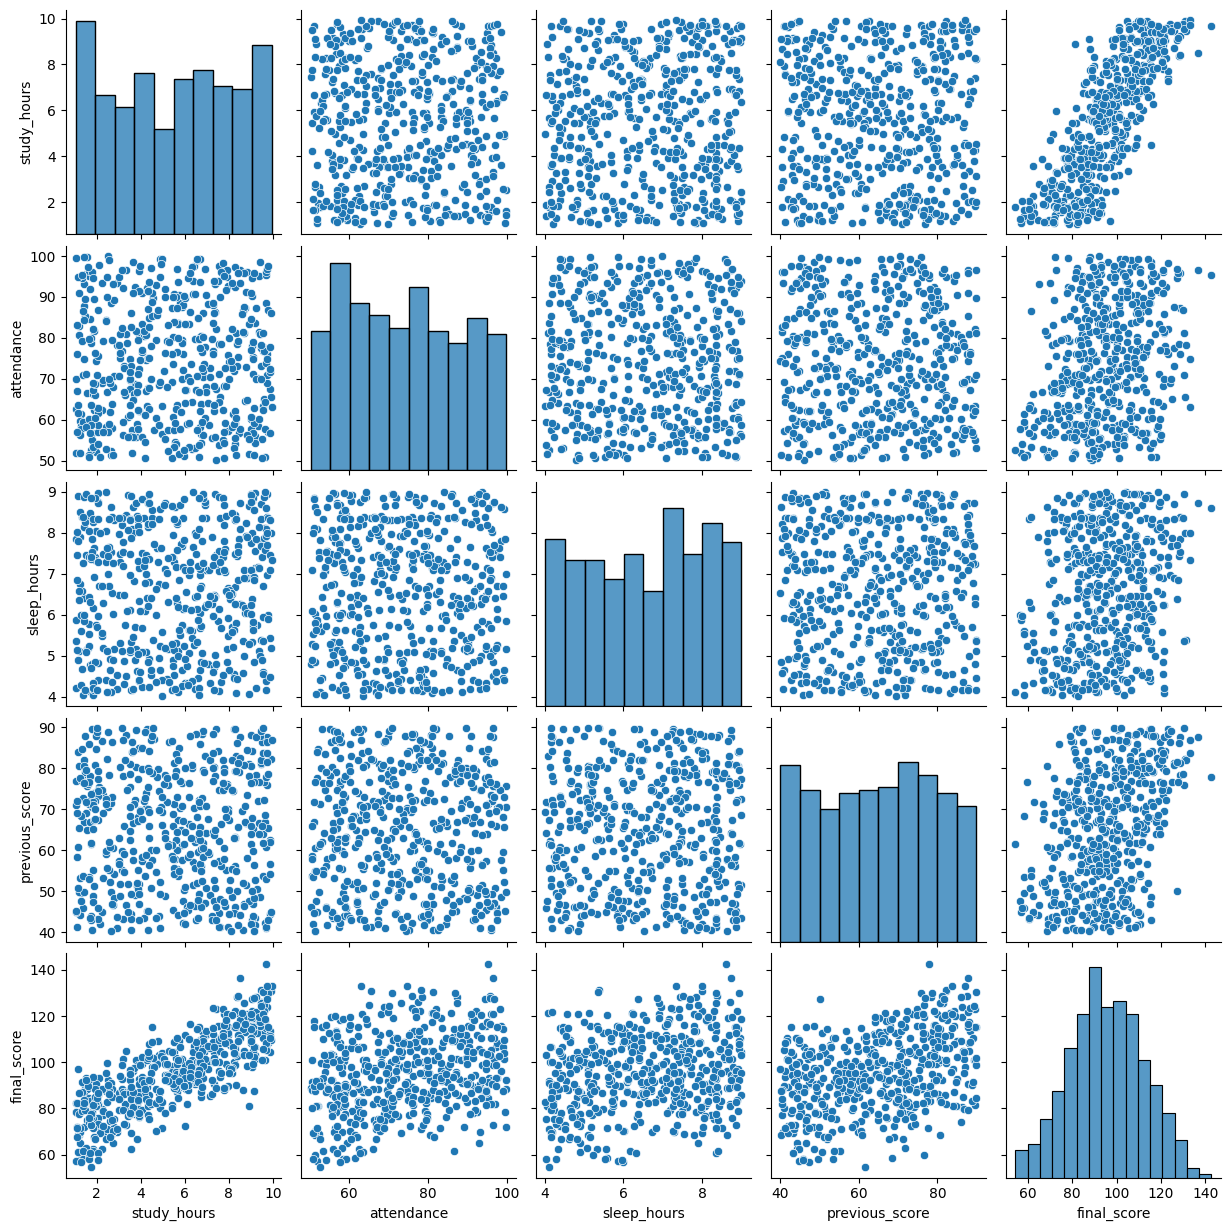

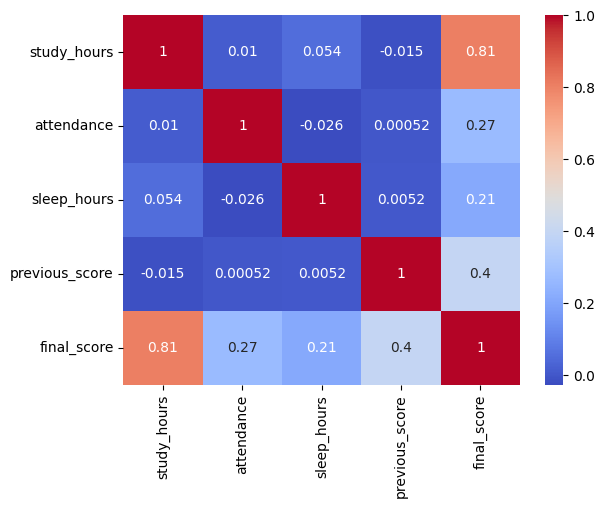

In [3]:
sns.pairplot(data)
plt.show()

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data.drop('final_score', axis=1)
y = data['final_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2 Score:", r2_score(y_test, preds))

MAE: 3.749493779667464
RMSE: 4.690150634672862
R2 Score: 0.9028779930024368


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_preds))

RF R2: 0.8675732029809105


In [7]:
new_student = pd.DataFrame({
    'study_hours': [6],
    'attendance': [80],
    'sleep_hours': [7],
    'previous_score': [70]
})

prediction = rf.predict(new_student)
print("Predicted Score:", prediction[0])

Predicted Score: 100.19034046165018


In [10]:
import os
import joblib

# Create folder if not exists
os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(rf, 'models/student_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [11]:
os.makedirs('models', exist_ok=True)

In [13]:
os.makedirs('data', exist_ok=True)
data.to_csv('data/student_data.csv', index=False)

In [16]:
os.makedirs('outputs', exist_ok=True)
pd.DataFrame(preds).to_csv('outputs/predictions.csv', index=False)

In [18]:
os.makedirs('images', exist_ok=True)
plt.savefig('images/heatmap.png')

<Figure size 640x480 with 0 Axes>